In [245]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [246]:
df = pd.read_csv('/content/new_insurance_data (1) (1).csv')
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

#EDA
1. null values
2. duplicated
3. outliers
4. label encoding


In [248]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [249]:
df.dropna(inplace= True)

In [250]:
df.duplicated().sum()

np.int64(0)

In [251]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
Claim_Amount,0
past_consultations,0
num_of_steps,0
Hospital_expenditure,0
NUmber_of_past_hospitalizations,0


In [252]:
df.duplicated().sum()

np.int64(0)

In [253]:
#df.drop_duplicated().sum()

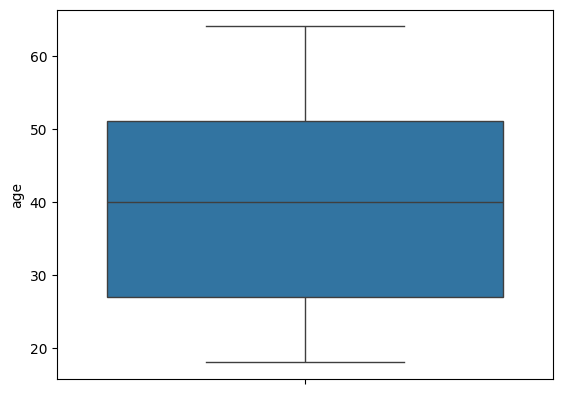

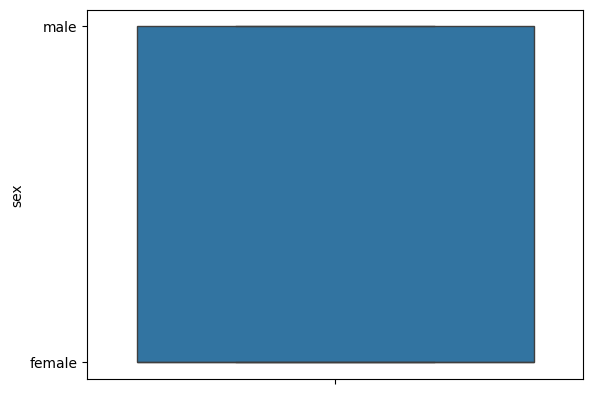

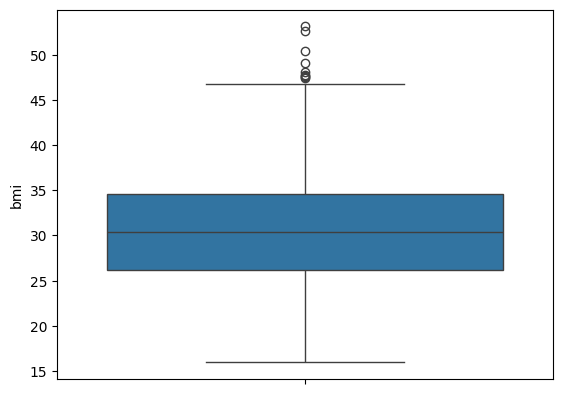

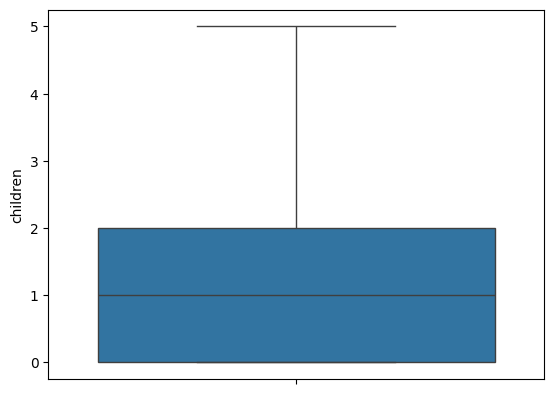

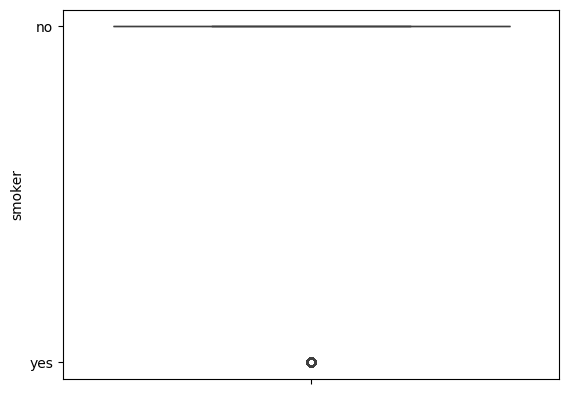

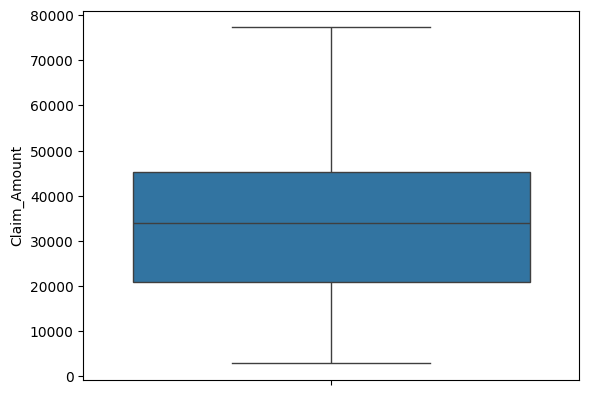

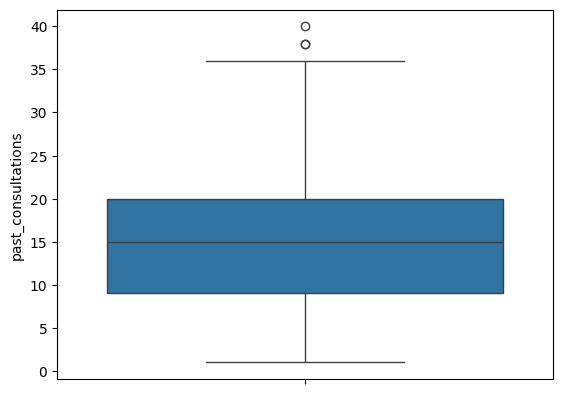

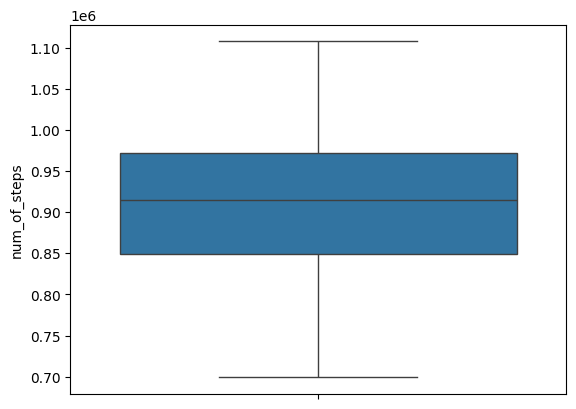

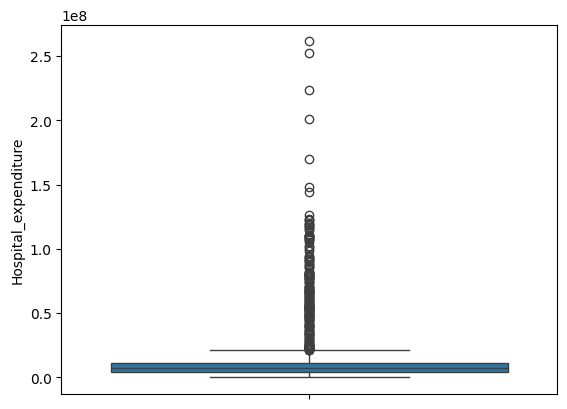

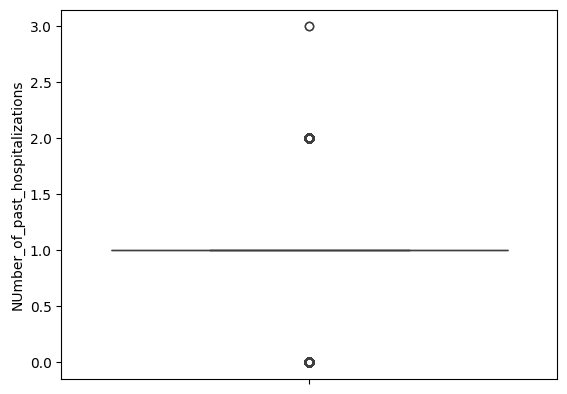

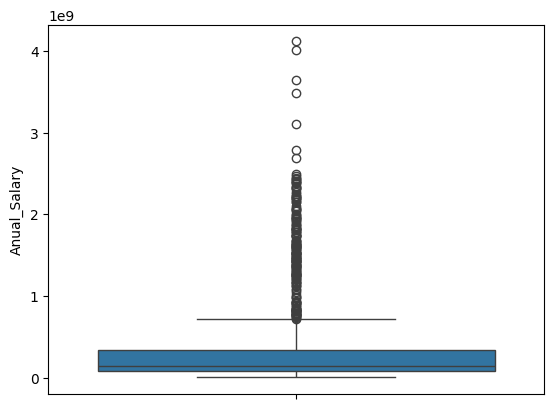

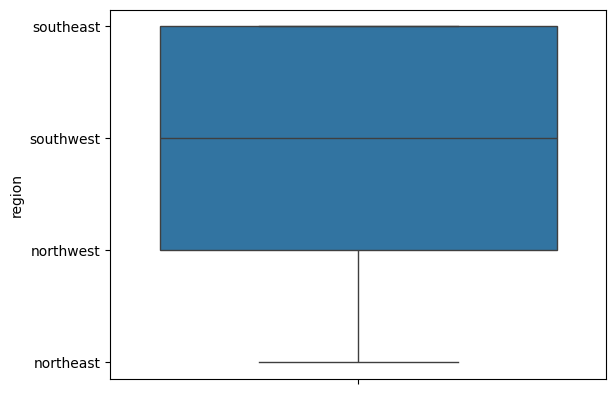

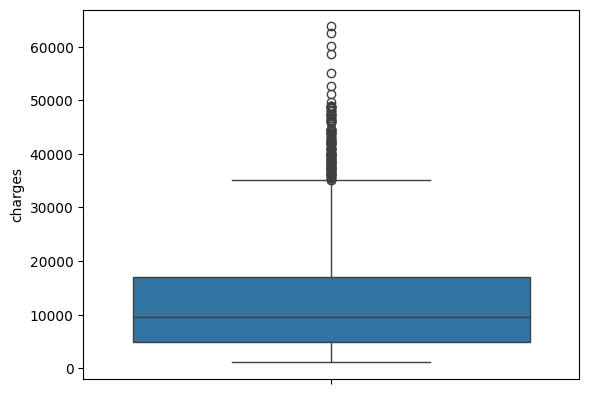

In [254]:
for col in df.columns:

    sns.boxplot(df[col])
    plt.xticks(rotation=90)
    plt.show()

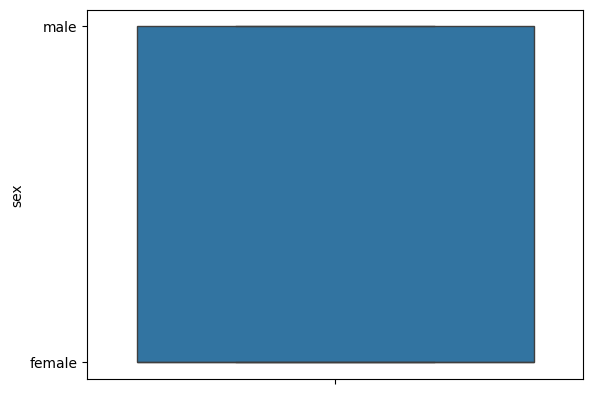

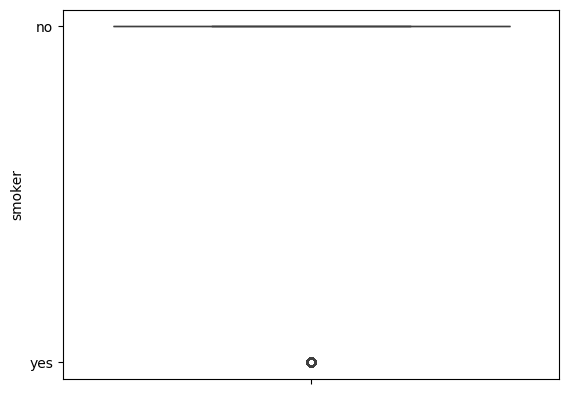

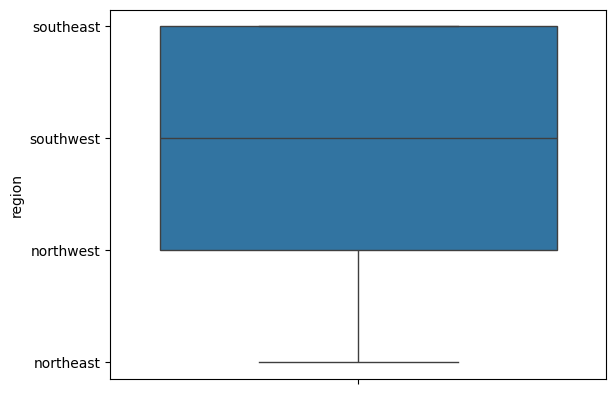

In [255]:
for col in df.columns:
  if (df[col].dtype == 'object'):
    sns.boxplot(df[col])
    plt.xticks(rotation=90)
    plt.show()


In [256]:
out_list = ['bmi','past_consultations','Hospital_expenditure','Anual_Salary']
for col in df.columns:
  if col in out_list:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [257]:
from sklearn.preprocessing import LabelEncoder

In [258]:
le = LabelEncoder()

In [259]:
for col in df.columns:
  if(df[col].dtype =='object'):
    df[col] = le.fit_transform(df[col])

In [260]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,43.0,1,20.13,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2,18767.73770
1041,24.0,0,27.60,0.0,0,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,3,18955.22017
1046,29.0,0,27.94,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1048,31.0,1,25.90,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3,19199.94400


In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 986 entries, 0 to 1050
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              986 non-null    float64
 1   sex                              986 non-null    int64  
 2   bmi                              986 non-null    float64
 3   children                         986 non-null    float64
 4   smoker                           986 non-null    int64  
 5   Claim_Amount                     986 non-null    float64
 6   past_consultations               986 non-null    float64
 7   num_of_steps                     986 non-null    float64
 8   Hospital_expenditure             986 non-null    float64
 9   NUmber_of_past_hospitalizations  986 non-null    float64
 10  Anual_Salary                     986 non-null    float64
 11  region                           986 non-null    int64  
 12  charges                   

In [262]:
#Statment: - Based om 12 columns bulid a model which will predict the charges values
x =df.drop('charges',axis=1)
y = df['charges']


In [263]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1036,43.0,1,20.13,2.0,1,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,2
1041,24.0,0,27.60,0.0,0,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,3
1046,29.0,0,27.94,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.90,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3


In [264]:
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1036,18767.73770
1041,18955.22017
1046,19107.77960
1048,19199.94400


In [265]:
from sklearn.model_selection import train_test_split

In [266]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30)

In [267]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
674,48.0,0,27.265,1.0,0,31860.216210,10.0,916653.0,4.611498e+06,1.0,1.291323e+08,0
483,39.0,1,24.510,2.0,0,18512.993280,16.0,884325.0,7.442466e+05,1.0,1.368503e+08,1
796,57.0,1,34.010,0.0,0,45662.375660,5.0,938783.0,4.158738e+06,1.0,1.683298e+08,1
436,39.0,1,26.220,1.0,0,24039.597510,19.0,869774.0,2.086179e+06,1.0,8.529027e+07,1
934,41.0,0,21.755,1.0,0,9350.194698,24.0,943323.0,3.078127e+06,1.0,2.344861e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
589,48.0,0,22.800,0.0,0,17700.018180,6.0,905879.0,7.244261e+06,1.0,1.508728e+08,3
598,46.0,1,38.170,2.0,0,41499.070200,10.0,894936.0,8.903075e+06,1.0,1.172087e+08,2
447,41.0,1,28.800,1.0,0,6810.905900,5.0,887851.0,7.168398e+06,1.0,1.371931e+08,3
1018,32.0,0,23.650,1.0,0,53840.228250,18.0,977689.0,7.081732e+06,1.0,3.390847e+08,2


In [268]:
from sklearn.linear_model import LinearRegression

In [269]:
model = LinearRegression()

In [270]:
model.fit(x_train,y_train)

LinearRegression()

In [271]:
model_answear = model.predict(x_test)

In [272]:
model_answear

array([ 9.60392955e+03,  7.88101691e+03,  1.12829999e+04,  6.43173202e+03,
        1.22523218e+04,  7.86612098e+03,  1.24553594e+04,  3.74929833e+03,
        5.87353076e+03,  5.72443199e+03,  2.11599142e+03,  4.33379536e+03,
        8.34329092e+03,  9.83121904e+03,  7.83851329e+03,  1.66823919e+04,
        5.05392906e+03,  1.07611755e+04,  5.05230961e+03,  2.61757808e+03,
        9.34621146e+03,  1.29489530e+04,  5.39005593e+03,  6.39343631e+03,
        1.84452998e+04,  8.19418895e+03,  1.76359244e+04,  9.28141520e+03,
        9.05907646e+03,  1.04019162e+04,  1.03097415e+04,  2.70630105e+03,
        1.01764648e+04,  3.45248557e+03,  6.77875919e+03,  2.96238394e+03,
        1.48632543e+04,  6.31666205e+03,  1.70064520e+03,  1.25460765e+04,
        1.20027584e+04,  6.72505208e+03,  1.13123585e+04,  1.24212692e+04,
        1.94324791e+03,  1.19758173e+04,  2.37895221e+03,  3.36399791e+03,
        4.42613818e+03,  1.07169570e+04,  3.15711410e+02,  1.85596549e+03,
        6.12407153e+03,  

In [273]:
from sklearn.metrics import r2_score

In [274]:
r2_score(y_test,model_answear)*100  #r2_score is the method is use to check the closeness between two variables

96.68402670314444

In [275]:
 # actual = 1119  , Predict =1118
 # we can`t say it`s a wrong ans
 # we can it`s correct prediction with error one

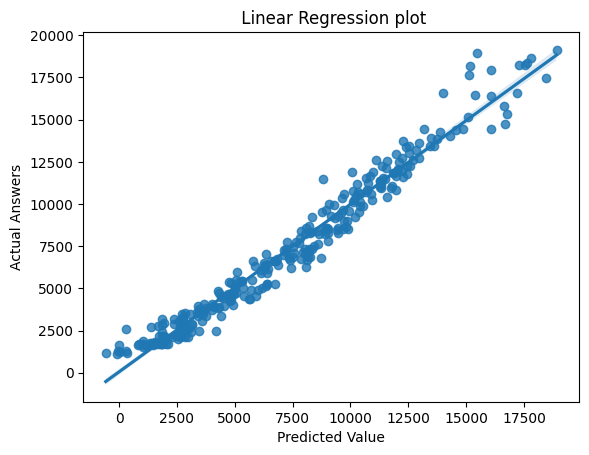

In [276]:
sns.regplot(y=y_test,x=model_answear)
plt.xlabel('Predicted Value')
plt.ylabel('Actual Answers')
plt.title(' Linear Regression plot')
plt.show()

In [277]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [278]:
Anup =[27,1,25.600,0.0,0,30825.190070,9.0,821360.0,5.923489e+06,0.0,7.490390e+07,2]

In [279]:
ay_data = pd.DataFrame(columns=x_train.columns)
ay_data

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region


In [280]:
ay_data.loc[0] = Anup

In [281]:
ay_data

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,27.0,1.0,25.6,0.0,0.0,30825.19007,9.0,821360.0,5923489.0,0.0,74903900.0,2.0


In [282]:
answer = model.predict(ay_data)

In [283]:
answer

array([5441.11283634])